In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from src import soporte_correlacion as sp_corr

pd.set_option("display.max_columns",None) #display todas las columnas
df_hr = pd.read_csv("files/hr_final.csv",index_col=0)

## Controlamos las advertencias
import warnings 
warnings.filterwarnings('ignore', category=FutureWarning) # Para ignorar las advertencias de tipo FutureWarning


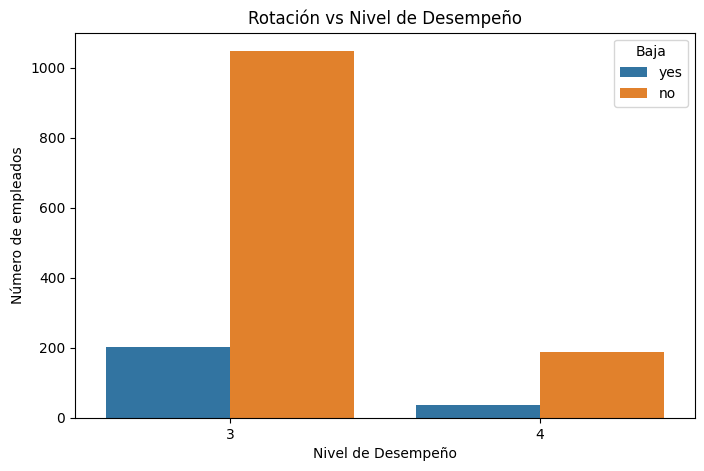

In [3]:


# Asegúrate de que tu dataframe se llama df
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_hr,
    x="performance_rating",
    hue="attrition"
)

plt.title("Rotación vs Nivel de Desempeño")
plt.xlabel("Nivel de Desempeño")
plt.ylabel("Número de empleados")
plt.legend(title="Baja")

plt.show()

In [4]:
#No vemos ningún patrón claro en que el nivel de desempeño tenga que ver con la rotación.Sin embargo podemos ver una tendencia y una área de mejora:
#Podemos observar :
#El performance rating es alto ya que es 3 de 4 y se podía aún mejorar ofreciendo más formación a los empleados.

In [5]:
df_rate = pd.crosstab(df_hr['job_role'], df_hr['attrition'], normalize='index') * 100
df_rate.head(20)

attrition,no,yes
job_role,,
healthcare representative,93.129771,6.870229
human resources,75.471698,24.528302
laboratory technician,76.061776,23.938224
manager,95.098039,4.901961
manufacturing director,93.150685,6.849315
research director,97.500000,2.500000
research scientist,83.959044,16.040956
sales executive,82.568807,17.431193
sales representative,60.240964,39.759036


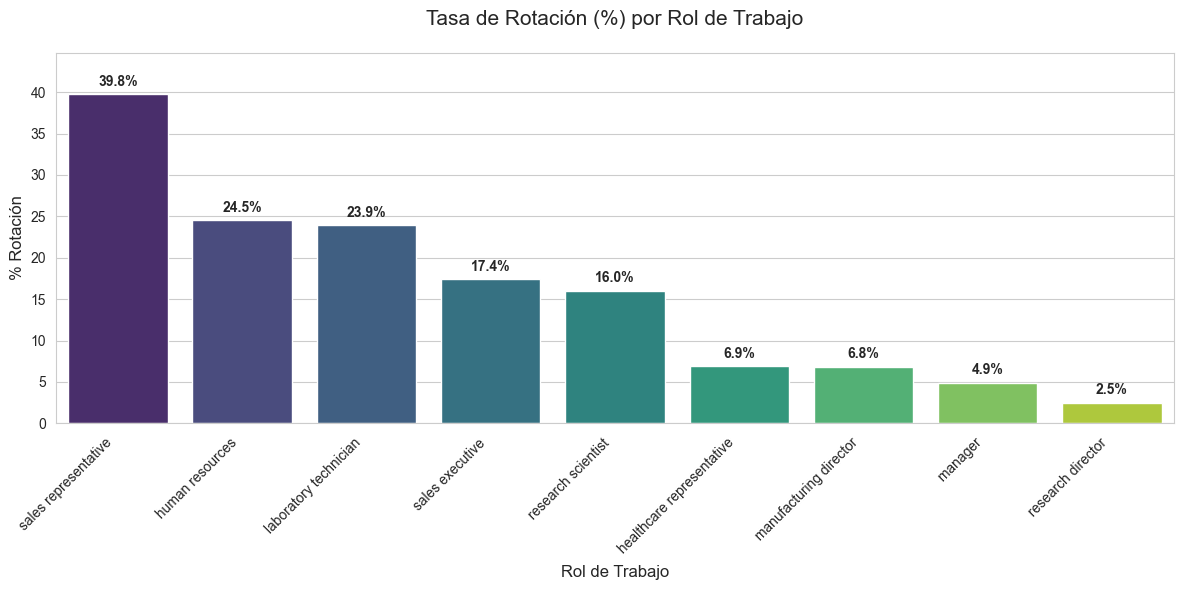

In [6]:

# 1. Tabla cruzada
df_rate = pd.crosstab(df_hr['job_role'], df_hr['attrition'], normalize='index') * 100

# 2. Detectar automáticamente la columna de bajas
col_attrition = [col for col in df_rate.columns if str(col).lower() in ['yes', '1', 'true']][0]

# 3. Crear columna final
df_rate['attrition_rate'] = df_rate[col_attrition]

# Reset index
df_rate = df_rate.reset_index()

# 4. ORDENAR (muy importante para insight 🔥)
df_rate = df_rate.sort_values(by='attrition_rate', ascending=False)

# 5. Gráfico
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

ax = sns.barplot(x='job_role',y='attrition_rate',data=df_rate,palette='viridis')

# 6. Estética (CORREGIDA)
plt.title('Tasa de Rotación (%) por Rol de Trabajo', fontsize=15, pad=20)
plt.ylabel('% Rotación', fontsize=12)
plt.xlabel('Rol de Trabajo', fontsize=12)
plt.ylim(0, df_rate['attrition_rate'].max() + 5)

# Rotar etiquetas (clave si hay muchos roles)
plt.xticks(rotation=45, ha='right')

# 7. Etiquetas
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show();

# Interpretaciones

1. Fuga crítica concentrada en roles comerciales
Sales Representative (~39.8%) es, con diferencia, el peor.
Luego Sales Executive (~17.4%) también está relativamente alto.

2. Recursos Humanos sorprendentemente alto (~24.5%)
Es el segundo rol con más rotación.

3. Alta estabilidad en roles senior
Manager (~4.9%)
Research Director (~2.5%)
Manufacturing Director (~6.8%)

👉 Insight:
Los roles altos tienen muy baja rotación.